# Study 01 — Field Size and Race Predictability

## Research question

**What relationship, if any, exists between field size and the predictability of British horse races?**

A familiar racing idea is that races with more runners are harder to predict. That sounds plausible: more horses means more possible winners, more traffic, more tactical complications and potentially more ways for a race to unfold unexpectedly.

But plausibility is not evidence.

This study starts with the question rather than assuming the answer.

## Purpose

The aim is to examine how race predictability changes, if at all, as field size increases.

“Predictability” will not automatically be reduced to a single statistic. Different measures may tell us different things. For example, we may want to distinguish between:

* how often the market's most strongly fancied runners actually win;
* how concentrated or uncertain the betting market is;
* whether market probabilities remain well calibrated as fields become larger.

These are related questions, but they are not interchangeable.

In particular, a lower favourite win rate in larger fields would not by itself prove that the betting market performs worse. With more runners, even a perfectly functioning market may assign a lower probability to its favourite.

Profitability is also a separate question. A horse or group of horses winning more or less often does not tell us whether backing them would have made money.

## Research principle

> **The evidence writes the story; the story does not decide what evidence we need.**

The study will therefore proceed descriptively first. We will inspect what the data actually contains, explain each result as it appears, and only introduce further comparisons, groupings or statistical models when the evidence gives us a reason to do so.

Unexpected, weak or null results are just as valid as a strong relationship.

## Initial scope

* **Population:** British horse races represented in the Inside Rails racing database.
* **Unit of analysis:** one race.
* **Field size:** the number of runners actually admitted to the reconstructed race.
* **Approach:** begin with exact field sizes rather than imposing arbitrary categories such as “small”, “medium” and “large”.
* **Interpretation:** describe associations rather than make unsupported causal claims.

Where several horses share favouritism, they will be treated as the **favourite set** rather than duplicating the race into multiple observations. A favourite success will mean that the eventual winner belonged to that set.

## Data used in this study

This study uses the **Inside Rails racing database**, containing historical race and runner records prepared specifically for analysis.

The underlying data has been checked and structured before being used here, including work to identify duplicate races, establish consistent race identities, verify runner counts and distinguish British racing from similarly named courses elsewhere.

That matters because the aim is not simply to calculate statistics from whatever happens to be recorded in the source data. We first need reasonable confidence that the races and runners being counted represent what we think they do.

The detailed validation work is documented separately. This notebook can therefore concentrate on the racing question while retaining an audit trail back to the underlying data and the decisions used to prepare it.

## Starting point

Before measuring predictability, we first need to establish **what British field sizes actually look like in the data**.

The first analytical step is therefore simply to count the number of British races at each observed field size. That gives us the population on which everything that follows will depend and shows where the data is plentiful or sparse before we start comparing outcomes.


In [2]:
from pathlib import Path
import sys

import pandas as pd


# Resolve the repository root whether Jupyter was started from the project
# root or from studies/. All study paths should remain repository-relative.
ROOT = Path.cwd()
if ROOT.name == "studies":
    ROOT = ROOT.parent

# Reuse tested Inside Rails code instead of reproducing governed logic inside
# the notebook.
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from inside_rails.source_sqlite import connect_read_only
from inside_rails.course_jurisdiction import derive_candidate_race_jurisdiction


# Reader-facing studies use the formally accepted Database v1 release.
# The raw source and preserved candidate are not normal analytical inputs.
DATABASE = (
    ROOT
    / "data"
    / "processed"
    / "database"
    / "releases"
    / "inside_rails_v1.sqlite3"
)


# This stage works at race grain: one row per governed race occurrence.
#
# The race view supplies the stable race identity and actual admitted runner
# count. Race name and type are taken from the runner view only because the
# already-governed jurisdiction helper needs them to resolve known course-name
# collisions such as Ascot and Newcastle.
query = """
SELECT
    race.source_race_occurrence_code,
    race.raw_date AS date,
    race.raw_course AS course,
    race.raw_off AS off,
    race.admitted_runner_count,
    MIN(runner.race_name) AS race_name,
    MIN(runner.type) AS type
FROM view_core_source_race_occurrences AS race
JOIN view_core_runner_participations AS runner
  ON runner.source_race_occurrence_code = race.source_race_occurrence_code
GROUP BY
    race.source_race_occurrence_code,
    race.raw_date,
    race.raw_course,
    race.raw_off,
    race.admitted_runner_count
"""


# Open the accepted release read-only and explicitly enforce the normal
# consumer safeguards before executing study SQL.
with connect_read_only(DATABASE) as connection:
    connection.execute("PRAGMA query_only = ON")
    connection.execute("PRAGMA foreign_keys = ON")
    connection.execute("PRAGMA trusted_schema = OFF")

    races = pd.read_sql_query(query, connection)


# These assertions protect the intended analytical grain.
# Before any British-racing filter, we should still have exactly the complete
# Database v1 population of 189,043 unique race occurrences.
assert len(races) == 189_043
assert races["source_race_occurrence_code"].is_unique


# Do not create a new ad-hoc "British course" rule in this study.
# Reuse the source-wide jurisdiction logic already established and validated
# earlier in the project.
races[
    ["candidate_jurisdiction", "jurisdiction_evidence_source"]
] = races.apply(
    derive_candidate_race_jurisdiction,
    axis=1,
)


# The research question concerns British racing, so this is the first
# population-changing analytical filter. Keep `races` intact so the size and
# effect of that filter remain visible.
british_races = races.loc[
    races["candidate_jurisdiction"] == "Great Britain"
].copy()


# Inspect field size in its original count form first.
# We deliberately do not invent "small", "medium" or "large" field buckets
# until the observed distribution gives us a reason to do so.
field_size_distribution = (
    british_races["admitted_runner_count"]
    .value_counts()
    .sort_index()
    .rename_axis("field_size")
    .rename("race_count")
    .reset_index()
)


# Keep the population denominator visible beside the first descriptive result.
print(f"All reconstructed races: {len(races):,}")
print(f"British races: {len(british_races):,}")
print()

display(field_size_distribution)

All reconstructed races: 189,043
British races: 111,634



,field_size,race_count
0,1,21
1,2,320
2,3,1708
3,4,4864
4,5,8829
5,6,11922
6,7,13855
7,8,14295
8,9,13304
9,10,11765


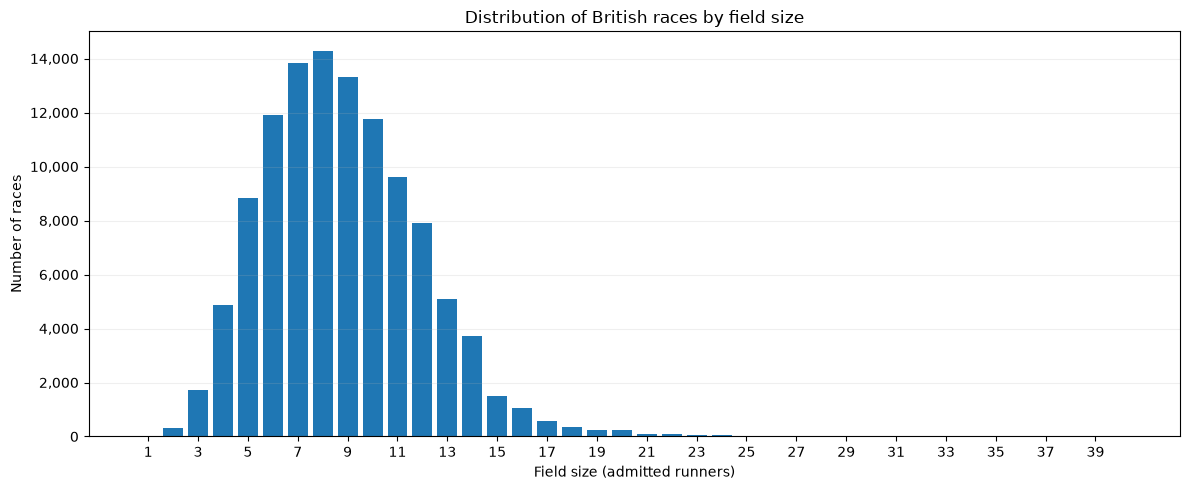

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter


# Field size is a discrete count, so a bar chart is the clearest way to show
# how the 111,634 British races are distributed across the exact observed
# number of admitted runners.
#
# Keep exact field sizes rather than introducing arbitrary categories. This
# preserves the actual shape of the population and makes the sparse tail
# visible before any later decisions about grouping.
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    field_size_distribution["field_size"],
    field_size_distribution["race_count"],
)


# This chart describes the study population only. The title deliberately
# avoids implying that anything has yet been learned about predictability.
ax.set_title("Distribution of British races by field size")
ax.set_xlabel("Field size (admitted runners)")
ax.set_ylabel("Number of races")


# The observed range extends to 40 runners. Labelling every integer would
# overcrowd the x-axis, so show alternate field sizes while retaining every
# bar in the chart.
maximum_field_size = int(field_size_distribution["field_size"].max())
ax.set_xticks(range(1, maximum_field_size + 1, 2))


# Use readable race counts and a light guide to make differences between
# neighbouring field sizes easier to judge.
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

### What the field-size distribution shows

The British study population contains **111,634 races**, giving the study a large overall sample.

Field sizes are not evenly distributed. The most common field size is **8 runners**, and the median is **9 runners**. Most British races sit within a fairly narrow central range: **74.0%** have between **6 and 12 runners**, while **89.8%** have between **5 and 14 runners**.

Beyond that central range, the number of observations falls away quickly. Only **4.0%** of races have 15 or more runners, and extremely large fields are rare.

For the field sizes in which the great majority of British racing occurs, the sample is therefore comfortably large enough for precise descriptive analysis. Individual field sizes from roughly **5 to 16 runners** are represented by thousands, or at least around a thousand, races. The principal sample-size limitation is in the sparse tail: from around 17 runners onward the number of races falls increasingly quickly, so estimates for the largest exact field sizes will carry substantially greater uncertainty.

This means later comparisons should retain the **number of races at each field size** alongside measures of predictability, rather than treating an estimate based on 10,000 races as equivalent to one based on only a few dozen.

At this stage, however, this is **only a description of the race population**. It does not show that larger fields are more or less predictable, and it does not yet justify combining field sizes into arbitrary categories such as “small”, “medium” and “large”.


### Checking the one-runner races

The field-size distribution contains **21 British races with only one admitted runner**.

These are unusual enough to inspect before continuing. If they are genuine single-runner events, their outcome is effectively predetermined and they may need to be treated separately from competitive races in any analysis of predictability.

We will inspect all 21 rather than assuming either that they are errors or that they are legitimate.


In [8]:
# One-runner races are analytically unusual because there is no competitive
# uncertainty if only one horse genuinely participates.
#
# Inspect every such race before deciding whether it belongs in the main
# predictability population. Nothing is excluded at this stage.
one_runner_race_codes = british_races.loc[
    british_races["admitted_runner_count"] == 1,
    "source_race_occurrence_code",
].tolist()

assert len(one_runner_race_codes) == 21


# Identify the governed local-time field from the accepted race-level view.
# Database v1 stores both resolved UTC time and pre-calculated local civil time;
# the reader-facing table should use the latter rather than the raw `off` value.
with connect_read_only(DATABASE) as connection:
    connection.execute("PRAGMA query_only = ON")
    connection.execute("PRAGMA foreign_keys = ON")
    connection.execute("PRAGMA trusted_schema = OFF")

    race_view_columns = [
        row[1]
        for row in connection.execute(
            "PRAGMA table_info(view_core_source_race_occurrences)"
        ).fetchall()
    ]


# Prefer a dedicated local-time field rather than a local datetime or timezone
# field. Fail loudly if the accepted schema does not contain exactly one clear
# match, rather than silently falling back to raw `off`.
local_time_candidates = [
    column
    for column in race_view_columns
    if "local" in column.lower()
    and "time" in column.lower()
    and "date" not in column.lower()
    and "zone" not in column.lower()
]

assert len(local_time_candidates) == 1, (
    "Expected exactly one governed local race-time column; found "
    f"{local_time_candidates}"
)

local_time_column = local_time_candidates[0]


# Retrieve race-level date and governed local time from the structural race
# view, then join the runner details needed to establish whether each
# one-runner event is genuinely a walkover.
placeholders = ", ".join("?" for _ in one_runner_race_codes)

query = f"""
SELECT
    race.source_race_occurrence_code,
    race.raw_date AS date,
    race."{local_time_column}" AS local_time,
    race.raw_course AS course,
    runner.race_name,
    runner.type,
    runner.ran,
    runner.horse,
    runner.pos,
    runner.comment
FROM view_core_source_race_occurrences AS race
JOIN view_core_runner_participations AS runner
  ON runner.source_race_occurrence_code = race.source_race_occurrence_code
WHERE race.source_race_occurrence_code IN ({placeholders})
ORDER BY
    race.raw_date,
    race.raw_course,
    race."{local_time_column}"
"""


with connect_read_only(DATABASE) as connection:
    connection.execute("PRAGMA query_only = ON")
    connection.execute("PRAGMA foreign_keys = ON")
    connection.execute("PRAGMA trusted_schema = OFF")

    one_runner_details = pd.read_sql_query(
        query,
        connection,
        params=one_runner_race_codes,
    )


# The structural race view says these are 21 one-runner races. Confirm that the
# joined records preserve exactly one row per race before interpreting them.
assert len(one_runner_details) == 21
assert one_runner_details["source_race_occurrence_code"].nunique() == 21


# Create a clean reader-facing copy. Keep the internal race identifier in the
# analytical dataframe for auditability, but do not display it to readers.
reader_walkovers = one_runner_details[
    [
        "date",
        "course",
        "local_time",
        "race_name",
        "type",
        "ran",
        "horse",
        "pos",
        "comment",
    ]
].copy()


# Remove source HTML line-break artefacts from presentation only. The original
# source value remains unchanged in `one_runner_details` and Database v1.
reader_walkovers["comment"] = (
    reader_walkovers["comment"]
    .str.replace(r"<br\s*/?>", "", regex=True)
    .str.strip()
)

display(reader_walkovers)

AssertionError: Expected exactly one governed local race-time column; found []

### What the one-runner races show

All **21 one-runner races are genuine walkovers**. The source comments explicitly record every case as either “Walked over” or “Walkover”.

This therefore appears to be a real feature of the racing record rather than an error in the reconstructed field-size data.

Walkovers should not be treated as ordinary races when measuring predictability. With only one admitted runner there is no competitive uncertainty: provided the horse completes the formal requirements, there is no rival capable of winning instead.

Including these races in measures such as favourite win rate would therefore introduce observations that are fundamentally different from competitive races and would artificially inflate apparent predictability at a field size of one.

The main predictability analysis will consequently use **competitive British races with at least two admitted runners**. The 21 walkovers will remain documented rather than being silently discarded.

After removing them, the competitive study population contains **111,613 races**.

No additional chart is needed for this check because every one-runner observation has the same substantive explanation.
